In [132]:
from keras.datasets.mnist import load_data
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from keras.models import Sequential
from keras.layers import Input,Flatten,Dense,Activation
from sklearn.metrics import accuracy_score,ConfusionMatrixDisplay,recall_score

In [105]:
(X_train,y_train),(X_test,y_test) = load_data()

In [106]:
y_train=pd.get_dummies(y_train,dtype='float32')
y_train

,0,1,2,3,4,5,6,7,8,9
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...
59995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
59996,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
59997,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
59998,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [107]:
y_test=pd.get_dummies(y_test,dtype='float32')
y_test

,0,1,2,3,4,5,6,7,8,9
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
9995,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9996,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
9997,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
9998,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [108]:
X_train.shape,y_train.shape

((60000, 28, 28), (60000, 10))

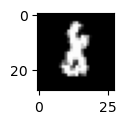

In [109]:
plt.figure(figsize=[1,1])
k =np.random.randint(60000)
plt.imshow(X_train[k],cmap='gray')
plt.show()

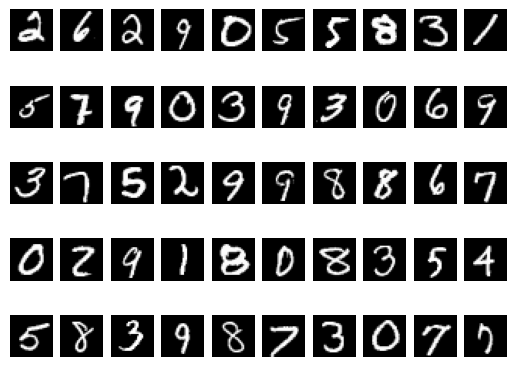

In [110]:
def display_images(nrows,ncols):
    for i in range(1,nrows*ncols+1):
        plt.subplot(nrows,ncols,i)
        k =np.random.randint(60000)
        plt.imshow(X_train[k],cmap='gray')
        plt.axis('off')
    plt.show()
  
display_images(5,10)

In [111]:
from keras.models import Sequential
from keras.layers import Input,Flatten,Dense,Activation

In [112]:
model =Sequential()

model.add(Input(shape=(28,28)))
model.add(Flatten())

model.add(Dense(units=50))
model.add(Activation('relu'))

model.add(Dense(units=50))
model.add(Activation('relu'))

model.add(Dense(units=50))
model.add(Activation('relu'))

model.add(Dense(units=10))
model.add(Activation('softmax'))
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 50)             │        39,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_17 (Activation)      │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_18 (Activation)      │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │           510 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_19 (Activation)      │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,860 (175.23 KB)

 Trainable params: 44,860 (175.23 KB)

 Non-trainable params: 0 (0.00 B)

In [113]:
model.compile(optimizer = 'adam',loss='categorical_crossentropy')

In [114]:
from keras.losses import CategoricalCrossentropy

In [117]:
model.compile(optimizer = 'adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [118]:



model.fit(X_train,y_train,epochs=10,validation_split=0.1)


Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9679 - loss: 0.1164 - val_accuracy: 0.9653 - val_loss: 0.1434
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9701 - loss: 0.1026 - val_accuracy: 0.9623 - val_loss: 0.1499
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9720 - loss: 0.1001 - val_accuracy: 0.9655 - val_loss: 0.1602
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9717 - loss: 0.0965 - val_accuracy: 0.9680 - val_loss: 0.1275
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9739 - loss: 0.0924 - val_accuracy: 0.9695 - val_loss: 0.1194
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9745 - loss: 0.0869 - val_accuracy: 0.9683 - val_loss: 0.1322
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9753 - loss: 0.0846 - val_accuracy: 0.9663 - val_loss: 0.1332
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9757 - loss: 0.0849 -

In [120]:
model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9613 - loss: 0.1887   


[0.18868866562843323, 0.9613000154495239]

In [121]:
y_predict =model.predict(X_test)
y_predict.shape

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step   


(10000, 10)

In [127]:
y_predict=np.array([np.argmax(i) for i in y_predict])
y_predict


array([7, 2, 1, ..., 4, 5, 6])

In [126]:
y_true = np.array([np.argmax(i) for i in y_predict])
y_true

array([7, 2, 1, ..., 4, 5, 6])

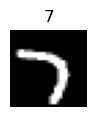

In [151]:
plt.figure(figsize=[1,1])
k =np.random.randint(10000)
plt.imshow(X_test[k],cmap='gray')
plt.title(y_predict[k])
plt.axis('off')
plt.show()

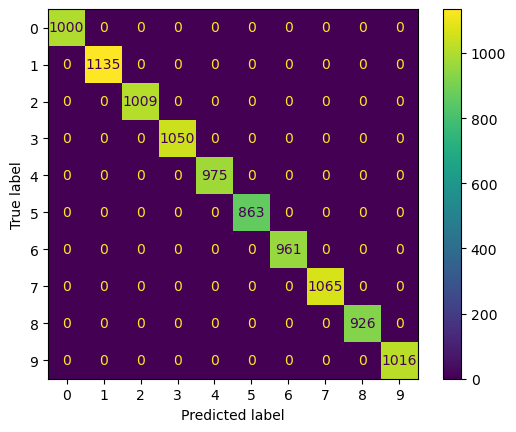

In [131]:
ConfusionMatrixDisplay.from_predictions(y_true,y_predict)
plt.show()

In [153]:
recall_score(y_true,y_predict,average='micro',labels=['7'])

1.0